In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
columns=["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]
df = pd.read_csv("processed.cleveland.data", names=columns)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
df.replace("?", pd.NA, inplace = True)
df = df.dropna()  # Droping missing rows
df = df.astype(float)

In [4]:
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)  # Converting into binary

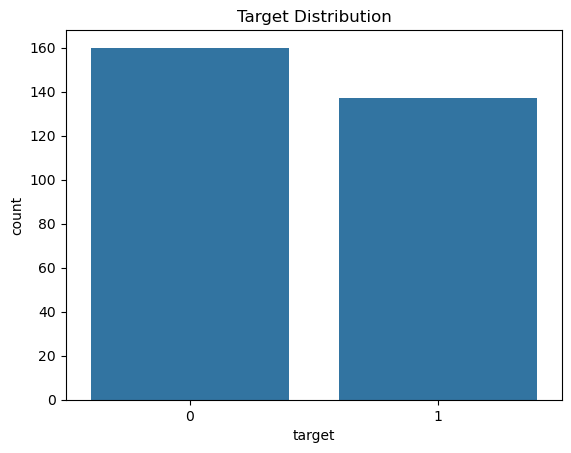

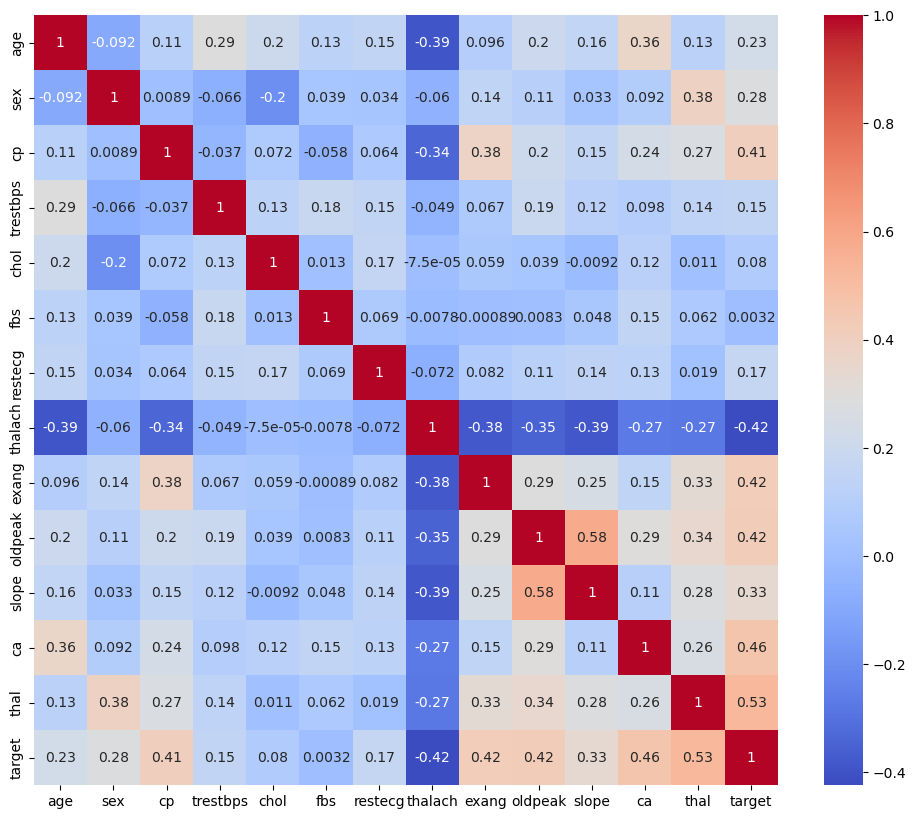

In [5]:
#Target Distribution
sns.countplot(x="target", data=df)
plt.title("Target Distribution")

#Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [6]:
X = df.drop("target", axis = 1)
y = df["target"]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# Train first model 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8666666666666667
Confusion Matrix:
 [[32  4]
 [ 4 20]]
ROC-AUC: 0.9421296296296298


In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

In [15]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

Random Forest Accuracy: 0.8833333333333333
Random Forest ROC-AUC: 0.9461805555555556


In [16]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob))

Logistic Regression Accuracy: 0.8666666666666667
Logistic Regression ROC-AUC: 0.9421296296296298


In [17]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

     Feature  Importance
7    thalach    0.128595
11        ca    0.128311
12      thal    0.104479
9    oldpeak    0.103659
2         cp    0.103653
4       chol    0.097724
0        age    0.094957
3   trestbps    0.089756
8      exang    0.052210
10     slope    0.033971
1        sex    0.032460
6    restecg    0.016737
5        fbs    0.013488


### Feature Importance Insights

1. **Maximum heart rate (thalach)** is the most important feature, indicating that cardiovascular performance during physical activity plays a crucial role in predicting heart disease.

2. **Number of major vessels (ca)** and **thalassemia (thal)** are highly influential, suggesting that structural and blood-related abnormalities significantly impact diagnosis.

3. **Oldpeak** and **chest pain type (cp)** show strong importance, highlighting ECG changes and symptomatic indicators as key predictors.

4. Features like **fasting blood sugar (fbs)** and **resting ECG (restecg)** have relatively low importance, indicating limited contribution in this dataset.

### Healthcare Insight

In healthcare applications, minimizing **false negatives** is critical, as missing a disease case can be life-threatening. Therefore, **ROC-AUC was prioritized over accuracy** for model evaluation.

### Model Comparison Insight

Random Forest outperformed Logistic Regression in both accuracy and ROC-AUC, indicating the presence of complex, non-linear relationships in the dataset.